In [52]:
import numpy as np
import pandas as pd

In [53]:
df = pd.read_csv("/home/junix/sms-spam-classifier/spam.csv", encoding="latin-1")
print(df)

        v1                                                 v2 Unnamed: 2  \
0      ham  Go until jurong point, crazy.. Available only ...        NaN   
1      ham                      Ok lar... Joking wif u oni...        NaN   
2     spam  Free entry in 2 a wkly comp to win FA Cup fina...        NaN   
3      ham  U dun say so early hor... U c already then say...        NaN   
4      ham  Nah I don't think he goes to usf, he lives aro...        NaN   
...    ...                                                ...        ...   
5567  spam  This is the 2nd time we have tried 2 contact u...        NaN   
5568   ham              Will Ì_ b going to esplanade fr home?        NaN   
5569   ham  Pity, * was in mood for that. So...any other s...        NaN   
5570   ham  The guy did some bitching but I acted like i'd...        NaN   
5571   ham                         Rofl. Its true to its name        NaN   

     Unnamed: 3 Unnamed: 4  
0           NaN        NaN  
1           NaN        NaN  


In [54]:
df.shape

(5572, 5)

In [55]:
# 1. cleeaning the data
# 2. EDA
# 3. Text Preprocessing
# 4. Model Building
# 5. Model Evaluation
# 6. Improvement
# 7. Website
# 8. Deploy

In [56]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   v1          5572 non-null   object
 1   v2          5572 non-null   object
 2   Unnamed: 2  50 non-null     object
 3   Unnamed: 3  12 non-null     object
 4   Unnamed: 4  6 non-null      object
dtypes: object(5)
memory usage: 217.8+ KB


In [57]:
df.drop(columns=["Unnamed: 2", "Unnamed: 3", "Unnamed: 4"], inplace=True)

In [58]:
df.head()

,v1,v2
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [59]:
df.rename(columns={"v1": "target", "v2": "text"}, inplace=True)
df.sample(8)

,target,text
1384,ham,"Storming msg: Wen u lift d phne, u say \HELLO\..."
2187,ham,Oh god. I'm gonna Google nearby cliffs now.
1345,ham,Que pases un buen tiempo or something like that
1542,ham,Now press conference da:)
3862,spam,Oh my god! I've found your number again! I'm s...
2226,ham,If you have belive me. Come to my home.
1874,spam,Would you like to see my XXX pics they are so ...
740,ham,Yes i will be there. Glad you made it.


In [60]:
df["target"] = df["target"].map({"ham": "0", "spam": "1"})
df.sample(10)

,target,text
1026,0,Yes da. Any plm at ur office
1522,0,I thk u dun haf 2 hint in e forum already lor....
4874,0,I know dat feelin had it with Pete! Wuld get w...
3464,0,"Haha figures, well I found the piece and prisc..."
2168,0,Thx. All will be well in a few months
2103,0,Its a site to simulate the test. It just gives...
3606,0,I have no idea where you are
4339,0,I want to sent &lt;#&gt; mesages today. Thats...
3955,0,Haha... dont be angry with yourself... Take it...
3816,0,This is my number by vivek..


In [61]:
# df["target"] = (df["target"] == "ham").astype(int)
# df.head()

In [62]:
# from sklearn.preprocessing import LabelEncoder
# encoder = LabelEncoder()
# df["target"] = encoder.fit_transform(df["target"])
# df.head()

In [63]:
#checking for missing and duplicate values
print(df.isnull().sum())


target    0
text      0
dtype: int64


In [64]:
print(df.duplicated().sum())

403


In [65]:
df = df.drop_duplicates(keep="first")
print(df.duplicated().sum())

0


In [66]:
df.shape

(5169, 2)

In [67]:
df.value_counts()

target  text                                                                                                                                                                          
0        &lt;#&gt;  in mca. But not conform.                                                                                                                                              1
         &lt;#&gt;  mins but i had to stop somewhere first.                                                                                                                               1
         &lt;DECIMAL&gt; m but its not a common car here so its better to buy from china or asia. Or if i find it less expensive. I.ll holla                                              1
         and  picking them up from various points                                                                                                                                         1
         came to look at the flat, seems ok, in his 50s? * Is awa

In [68]:
df['target'].value_counts()

target
0    4516
1     653
Name: count, dtype: int64

In [69]:
import matplotlib.pyplot as plt
import seaborn as sns

([<matplotlib.patches.Wedge at 0x7fd953978440>,
 [Text(-1.014499732282844, 0.4251944181172162, 'ham'),
  Text(1.0144998708287172, -0.42519408755122207, 'spam')],
 [Text(-0.5533634903360967, 0.2319242280639361, '87.37'),
  Text(0.553363565906573, -0.231924047755212, '12.63')])

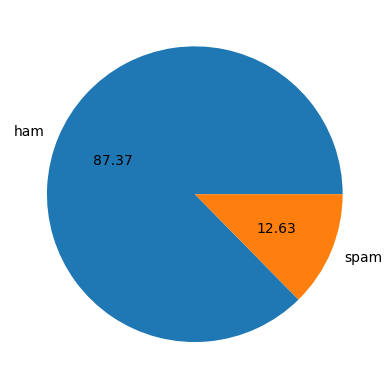

In [70]:
plt.pie(df['target'].value_counts(), labels=['ham', 'spam'], autopct="%0.2f")

In [71]:
#notice rhat the data is imbalanced!